En primer lugar, importamos todas las librerías necesarias:

In [30]:
#Importamos pandas
import pandas as pd 
#Importamos numpy
import numpy as np 
#Importamos datetime
import datetime as dt 

#Importación de visualizaciones
import seaborn as sns
import matplotlib.pyplot as plt

#Importamos nuestro archivo de soporte
import sys
sys.path.append('../')
from Jupyters.soporte_def import *

print ("Librerias importadas")

Librerias importadas


Importamos de nuevo el dataset:

In [31]:
df_original = pd.read_csv ("../Clean_Data/Dataframe_EDA.csv")
print ("Dataset importado")

Dataset importado


Por último copiamos el dataset a un dataset de trabajo:

In [32]:
df_EDA = df_original

print ("Dataset copiado")

Dataset copiado


Lo primero que vamos a hacer en esta parte del estudio es recordar el **objetivo de este EDA:**

- Impacto de las diferentes variables en la longevidad de un jugador. 

Esto hace que nuestra variable objetivo sea la **variable seniority.**

Vamos a enfocar esta parte del estudio de manera que estudiaremos primero la relación de las columnas numéricas con la variable objetivo y posteriormente las variables categóricas.

**1. Análisis de variables numéricas**

En primer lugar, extraemos las columnas numéricas de nuevo:

In [33]:
df_EDA.select_dtypes(include = np.number).columns

Index(['id', 'general_team', 'draft_team', 'seniority', 'from_year', 'to_year',
       'height_definitivo', 'weight', 'num_equipos'],
      dtype='str')

En primer lugar, vamos a obtener las correlaciones de todas las variables numéricas con la columna seniority:

In [34]:
correlaciones = df_EDA.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (correlaciones)

seniority            1.000000
num_equipos          0.583235
draft_team           0.328680
weight               0.145114
height_definitivo    0.062797
general_team        -0.043642
to_year             -0.103573
id                  -0.602711
from_year           -0.667920
Name: seniority, dtype: float64


Conclusiones: 
- Hay una correlación positiva bastante fuerte entre la variable num_equipos y la longevidad de un jugador en la liga indicando que los jugadores que más temporadas juegan en la liga tienden a cambiar más de equipos. 
- Hay una correlación negativa bastante fuerte entre seniority y la columna from_year indicando que los jugadores más antiguos tendían a jugar más temporadas en la NBA que los actuales.
 La primera justificación y más lógica para esto es que ya han podido completar su carrera mientras que los nuevos aún no. Por esto quizá convendría realizar un segundo análisis comparando solo la longevidad de los jugadores inactivos. 

- En el lado positivo observamos que la variable draft_team tiene una correlación positiva elevada con la longevidad lo que puede indicar que el equipo que te draftea tiene cierta influencia en tu longevidad como jugador. 

- Por último, destacar también que existe una correlación positiva moderada entre el peso de un jugador y su longevidad mostrando que posiblemente los jugadores más pesados tienen carreras ligeramente más largas. 


Vamos a intentar esclarecer la primera correlación que hemos destacado entre la longevidad y la antigüedad de un jugador. Para ello vamos a generar un nuevo dataset que tenga en cuenta solo a los jugadores retirados y vamos a analizar de esta forma la longevidad. 

In [35]:
#Generamos el nuevo dataset 
df_retirados = df_EDA[df_EDA['is_active']=='Inactive'].reset_index(drop = True)

#Sacamos la correlación de nuevo de todas las variables si los jugadores están retirados
corr_retirados = df_retirados.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_retirados)

seniority            1.000000
num_equipos          0.561892
draft_team           0.360577
weight               0.122684
height_definitivo    0.066930
to_year             -0.008378
general_team        -0.041507
id                  -0.528817
from_year           -0.652227
Name: seniority, dtype: float64


Como podemos observar, nuestra sospecha se confirma demostrando que los jugadores de antaño tendían a durar más tiempo en la liga en comparación a los jugadores actuales mientras que el resto de variables han parecido mantenerse también.

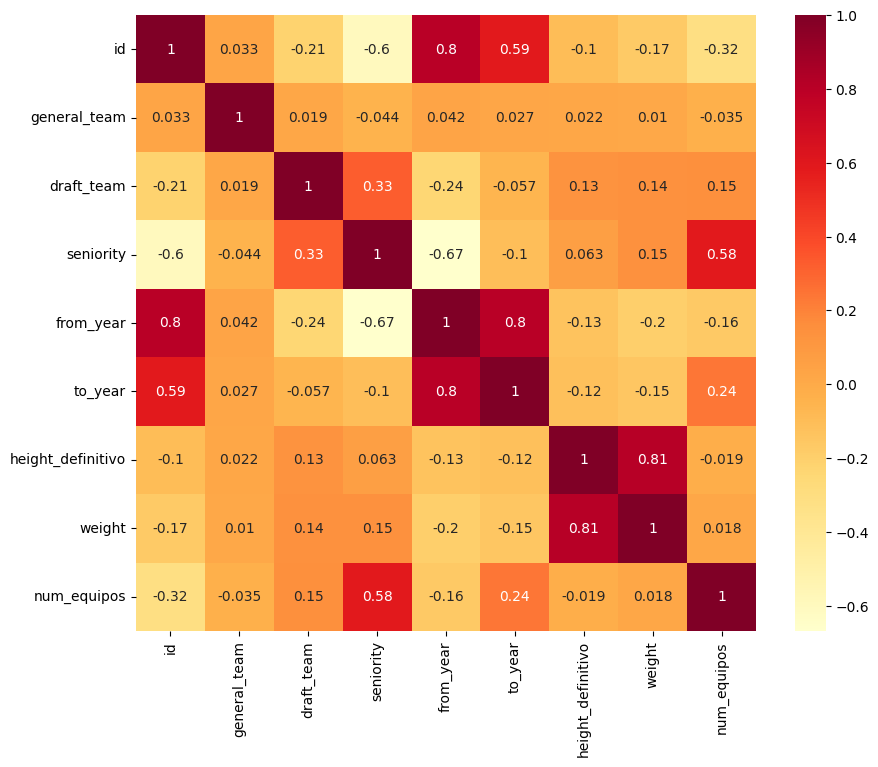

In [36]:
columns = ['id', 'general_team', 'draft_team', 'seniority', 'from_year', 'to_year',
       'height_definitivo', 'weight', 'num_equipos']
corr_fig(df_EDA, columns)

La única cosa que hemos visto es que como es de esperar en jugadores de baloncesto profesional, hay una correlación extremadamente fuerte entre la altura y el peso del jugador. 

**2. Análisis de las columnas categóricas**

Lo primero que hacemos como en el paso anterior es obtener las columnas categóricas: 

In [37]:
df_EDA.select_dtypes(include= 'object').columns

C:\Users\jdonderispla\AppData\Local\Temp\ipykernel_31364\4067663090.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_EDA.select_dtypes(include= 'object').columns


Index(['general_city', 'general_team_name', 'full_name', 'is_active',
       'draft_city', 'draft_team_name', 'organization_type', 'position',
       'g-league', 'greatest_75_flag', 'hub'],
      dtype='str')

Para realizar esta comparación, vamos a utilizar la función get_dummies para convertir las columnas categóricas en columnas numéricas. 
Una vez realizado ese trabajo, procederemos a analizar las correlaciones:

- Columna general_city

Esta columna tiene demasiadas categoría como para representarla en una matriz de correlaciones por lo que vamos a obtener las correlaciones entre cada categoría y seniority y a analizarlas sin un gráfico.

In [38]:
#Creamos las nuevas columnas con las categóricas
dummies_general_city = pd.get_dummies(df_EDA[['general_city']])

#Creamos un dataset con las nuevas columnas y la columna seniority 
df_corr_gen_city = pd.concat([dummies_general_city, df_EDA[['seniority']]], axis = 1)

print ("Dataset generado")

Dataset generado


In [39]:
#Obtenemos la correlación
corr_gen_city = df_corr_gen_city.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_gen_city)

seniority                     1.000000
general_city_Seattle          0.038792
general_city_New Jersey       0.037902
general_city_Los Angeles      0.037594
general_city_Miami            0.034794
general_city_Dallas           0.030422
general_city_Cleveland        0.016636
general_city_Orlando          0.015480
general_city_Chicago          0.010219
general_city_Denver           0.008295
general_city_New York         0.007026
general_city_Portland         0.005997
general_city_Minnesota        0.004880
general_city_Sacramento       0.002523
general_city_Brooklyn        -0.000007
general_city_Boston          -0.001529
general_city_Phoenix         -0.001565
general_city_Milwaukee       -0.001882
general_city_Philadelphia    -0.003703
general_city_Houston         -0.005777
general_city_Charlotte       -0.006129
general_city_Washington      -0.006754
general_city_Vancouver       -0.009283
general_city_Golden State    -0.010162
general_city_Atlanta         -0.010241
general_city_San Antonio 

Conclusión: 
- El análisis de correlaciones en esta variable muestra que ninguna de las ciudades presenta una correlación significativa con la longevidad de los jugadores. Esto sugiere que el jugar en una ciudad o otra no es un factor determinante en la longevidad de una carrera de un jugador.

- Columna general_team_name

En este caso, haremos lo mismo que con la columna anterior:

In [40]:
#Creamos las nuevas columnas con las categóricas
dummies_general_team = pd.get_dummies(df_EDA[['general_team_name']])

#Creamos un dataset con las nuevas columnas y la columna seniority 
df_corr_gen_team = pd.concat([dummies_general_team, df_EDA[['seniority']]], axis = 1)

print ("Dataset generado")


Dataset generado


In [41]:
#Obtenemos la correlación
corr_gen_team = df_corr_gen_team.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_gen_team)

seniority                          1.000000
general_team_name_SuperSonics      0.038792
general_team_name_Heat             0.034794
general_team_name_Bobcats          0.033903
general_team_name_Mavericks        0.030422
general_team_name_Lakers           0.028208
general_team_name_Nets             0.025297
general_team_name_Clippers         0.024060
general_team_name_Cavaliers        0.016636
general_team_name_Magic            0.015480
general_team_name_Bulls            0.010219
general_team_name_Nuggets          0.008295
general_team_name_Knicks           0.007026
general_team_name_Trail Blazers    0.005997
general_team_name_Timberwolves     0.004880
general_team_name_Kings            0.002523
general_team_name_Celtics         -0.001529
general_team_name_Suns            -0.001565
general_team_name_Bucks           -0.001882
general_team_name_76ers           -0.003703
general_team_name_Rockets         -0.005777
general_team_name_Wizards         -0.006754
general_team_name_Warriors      

Conclusión:
- Como en el caso de las ciudades, la variable general_team_name y la variable seniority no tienen correlaciones destacables por tanto podemos asumir que el equipo no es una variable determinante en la longevidad de un jugador.

- Columna is_active

In [42]:
#Creamos las nuevas columnas con las categóricas
dummies_active = pd.get_dummies(df_EDA[['is_active']])

#Creamos un dataset con las nuevas columnas y la columna seniority 
df_corr_active = pd.concat([dummies_active, df_EDA[['seniority']]], axis = 1)

print ("Dataset generado")

Dataset generado


In [43]:
#Obtenemos la correlación
corr_active = df_corr_active.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_active)

seniority             1.000000
is_active_Inactive    0.156038
is_active_Active     -0.156038
Name: seniority, dtype: float64


En este caso ya que tenemos menos categoría si que vamos a generar el mapa de correlaciones a través de una función predefinida:

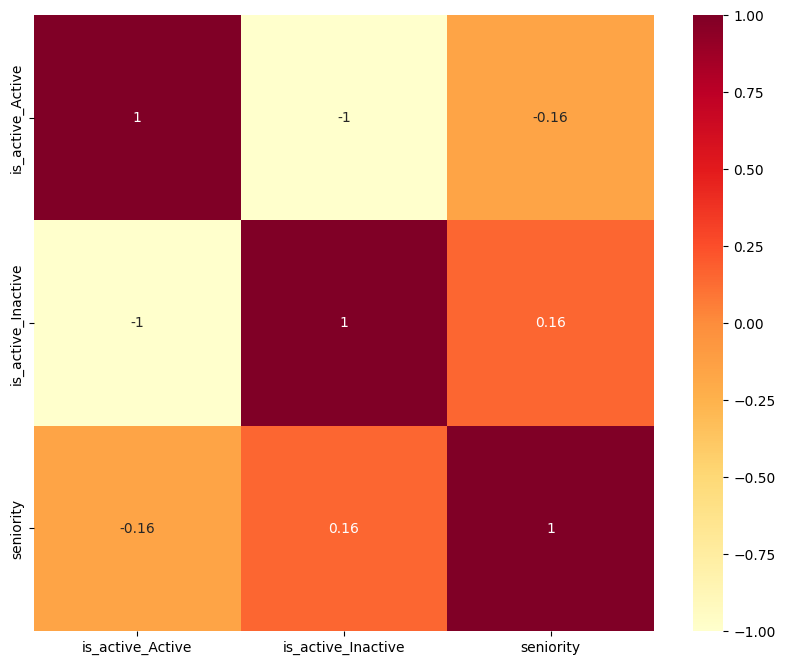

In [44]:
#Generamos el gráfico
active_col = df_corr_active.columns

#Generamos el gráfico
corr_fig(df_corr_active, active_col)

Conclusiones: 
- En este caso vemos una correlación positiva débil entre la categoría Inactive y Seniority. Al ser una columna con solo dos categorías es lógico que como observamos la categoría Active tenga una correlación simétrica opuesta a la de la columna Inactive. 
- Esto nos demuestra que como es de esperar los jugadores retirados tienden a jugar más temporadas ya que ya han finalizado su carrera. Este set ha sido simplemente para comprobar la coherencia de los datos.

- Columna draft_city

In [45]:
#Creamos las nuevas columnas con las categóricas
dummies_draft_city = pd.get_dummies(df_EDA[['draft_city']])

#Creamos un dataset con las nuevas columnas y la columna seniority 
df_corr_draft_city = pd.concat([dummies_draft_city, df_EDA[['seniority']]], axis = 1)

print ("Dataset generado")

Dataset generado


In [46]:
#Obtenemos la correlación
corr_draft_city = df_corr_draft_city.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_draft_city)

seniority                   1.000000
draft_city_Seattle          0.094356
draft_city_Cleveland        0.079900
draft_city_Denver           0.077996
draft_city_Los Angeles      0.059975
draft_city_Orlando          0.054258
draft_city_Phoenix          0.050635
draft_city_San Antonio      0.049858
draft_city_Utah             0.046109
draft_city_Detroit          0.043871
draft_city_Golden State     0.037873
draft_city_Chicago          0.031667
draft_city_Houston          0.030941
draft_city_Vancouver        0.030791
draft_city_Memphis          0.028854
draft_city_Washington       0.027900
draft_city_Boston           0.027442
draft_city_Atlanta          0.027184
draft_city_New Jersey       0.026806
draft_city_New York         0.026083
draft_city_Miami            0.022029
draft_city_Sacramento       0.019227
draft_city_Toronto          0.017846
draft_city_Milwaukee        0.012956
draft_city_Portland         0.011500
draft_city_Indiana          0.010566
draft_city_Charlotte        0.009645
d

En este caso, no vamos a generar el mapa de correlaciones tampoco debido a la gran cantidad de categorías en la variable.

Conclusiones:
- Hay una correlación moderada negativa entre la categoría undrafted y la longevidad de -0,329 lo que indica que los jugadores que no son drafteados tienden a tener carreras notablemente más cortas que los jugadores que fueron drafteados. Esto tiene sentido ya que estos jugadores no cuentan con el apoyo de una franquicia desde pronto en su carrera normalmente lo que les hace empezar también más tarde a jugar.
- El resto de ciudades presentan correlaciones muy débiles lo que indica que es irrelevante donde un jugador es drafteado en la longevidad de su carrera.

- Columnas draft_team_name

In [47]:
#Creamos las nuevas columnas con las categóricas
dummies_draft_team = pd.get_dummies(df_EDA[['draft_team_name']])

#Creamos un dataset con las nuevas columnas y la columna seniority 
df_corr_draft_team = pd.concat([dummies_draft_team, df_EDA[['seniority']]], axis = 1)

print ("Dataset generado")

Dataset generado


In [48]:
#Obtenemos la correlación
corr_draft_team = df_corr_draft_team.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_draft_team)

seniority                        1.000000
draft_team_name_SuperSonics      0.094356
draft_team_name_Clippers         0.086601
draft_team_name_Cavaliers        0.079900
draft_team_name_Nuggets          0.077996
draft_team_name_Bullets          0.070327
draft_team_name_Magic            0.054258
draft_team_name_Suns             0.050635
draft_team_name_Spurs            0.049858
draft_team_name_Jazz             0.046109
draft_team_name_Pistons          0.043871
draft_team_name_Bobcats          0.039934
draft_team_name_Grizzlies        0.038794
draft_team_name_Warriors         0.037873
draft_team_name_Bulls            0.031667
draft_team_name_Rockets          0.030941
draft_team_name_Celtics          0.027442
draft_team_name_Hawks            0.027184
draft_team_name_Knicks           0.026083
draft_team_name_Heat             0.022029
draft_team_name_Kings            0.019227
draft_team_name_Raptors          0.017846
draft_team_name_Bucks            0.012956
draft_team_name_Hornets          0

En este caso, no vamos a generar el mapa de correlaciones tampoco debido a la gran cantidad de categorías en la variable.

Conclusiones: 

En este caso, las conclusiones son las mismas que en la variable anterior.

- Columna organization_type

In [49]:
#Creamos las nuevas columnas con las categóricas
dummies_organization = pd.get_dummies(df_EDA[['organization_type']])

#Creamos un dataset con las nuevas columnas y la columna seniority 
df_corr_organization = pd.concat([dummies_organization, df_EDA[['seniority']]], axis = 1)

print ("Dataset generado")

Dataset generado


In [50]:
#Obtenemos la correlación
corr_organization = df_corr_organization.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_organization)

seniority                               1.000000
organization_type_College/University    0.219809
organization_type_High School           0.214086
organization_type_Other Team/Club      -0.014114
organization_type_Unknown              -0.329319
Name: seniority, dtype: float64


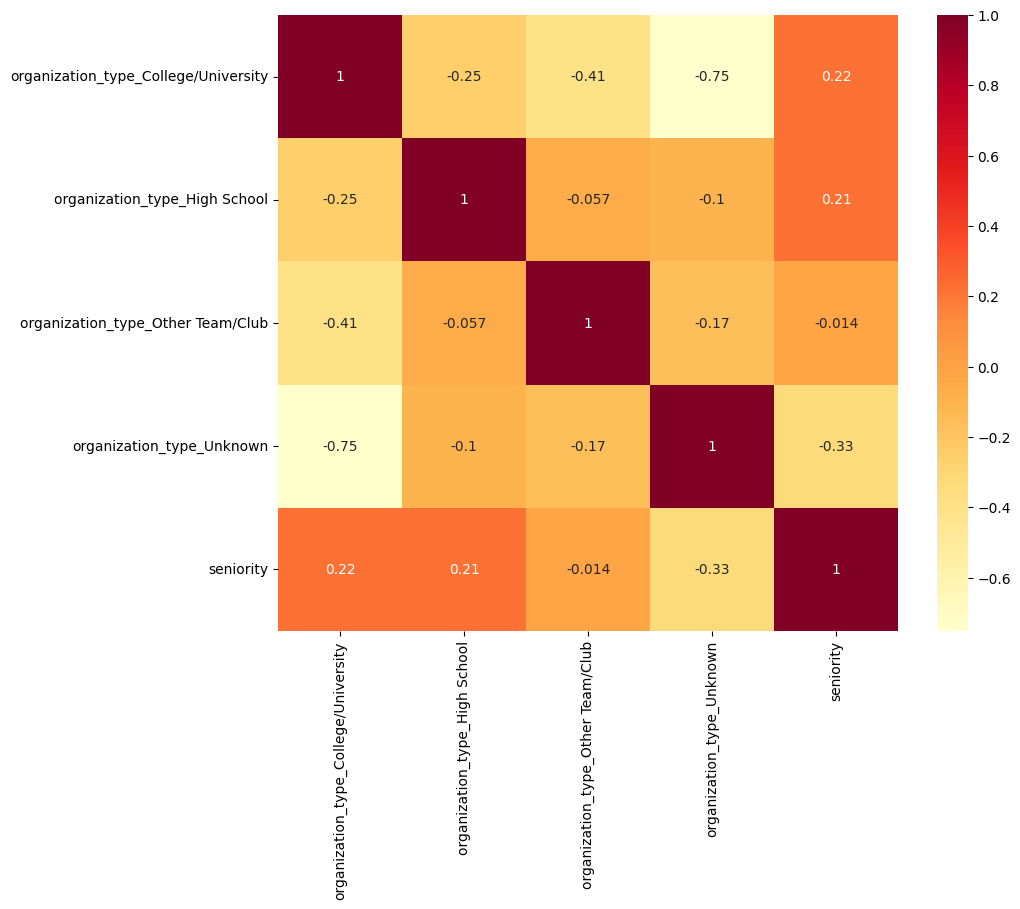

In [51]:
#Generamos el gráfico
organization_col = df_corr_organization.columns

#Generamos el gráfico
corr_fig(df_corr_organization, organization_col)

Conclusiones:
- Los jugadores que vienen de origen desconocido es decir otro que no son las categorías que ya tenemos presentan una correlación negativa moderada con la longevidad del jugador. Esto implica, que estos jugadores con origen desconocido tienden a tener carreras más cortas. Esto se puede deber a un sesgo en los datos creado durante la fase de limpieza 
- Las categoría college y high school presentan correlaciones positivas moderadas también y muy similares, de 0,220 y 0,214 respectivamente. Esto implica que los jugadores que vienen del sistema universitario estadounidense tienden a tener carreras más largas. 


- Columna position

In [52]:
#Creamos las nuevas columnas con las categóricas
dummies_position = pd.get_dummies(df_EDA[['position']])

#Creamos un dataset con las nuevas columnas y la columna seniority 
df_corr_position = pd.concat([dummies_position, df_EDA[['seniority']]], axis = 1)

print ("Dataset generado")

Dataset generado


In [53]:
corr_position = df_corr_position.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_position)

seniority                  1.000000
position_Center-Forward    0.096147
position_Forward-Center    0.047317
position_Center            0.015857
position_Guard-Forward     0.011630
position_Forward          -0.009386
position_Forward-Guard    -0.021647
position_Guard            -0.065403
Name: seniority, dtype: float64


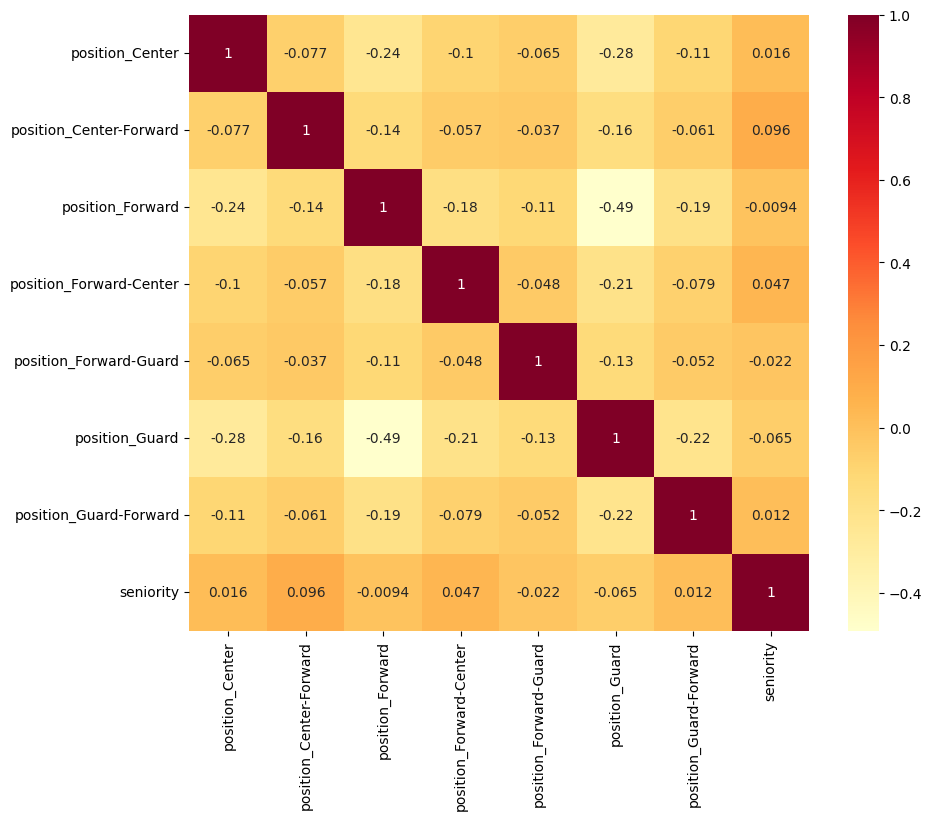

In [54]:
#Generamos el gráfico
position_col = df_corr_position.columns

#Generamos el gráfico
corr_fig(df_corr_position, position_col)

Conclusiones: 
- Ninguna columna presenta correlaciones fuertes con la columna seniority. 
- Las columnas relacionadas con los interiores muestran correlaciones positivas ligeramente más altas, esto nos lleva a pensar que los interiores pueden tener carreras ligeramente más largas. 
- El hecho de que un jugador pueda ocupar distintas posiciones no parece influir en la longevidad de su carrera. 
- Los jugadores en posiciones de guard muestran correlaciones negativas ligeramente más altas lo que implica carreras más cortas.

- Column g-league

In [58]:
#Creamos las nuevas columnas con las categóricas
dummies_gleague = pd.get_dummies(df_EDA[['g-league']])

#Creamos un dataset con las nuevas columnas y la columna seniority 
df_corr_gleague = pd.concat([dummies_gleague, df_EDA[['seniority']]], axis = 1)

print ("Dataset generado")

Dataset generado


In [60]:
corr_gleague = df_corr_gleague.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_gleague)

seniority       1.000000
g-league_No     0.542483
g-league_Yes   -0.542483
Name: seniority, dtype: float64


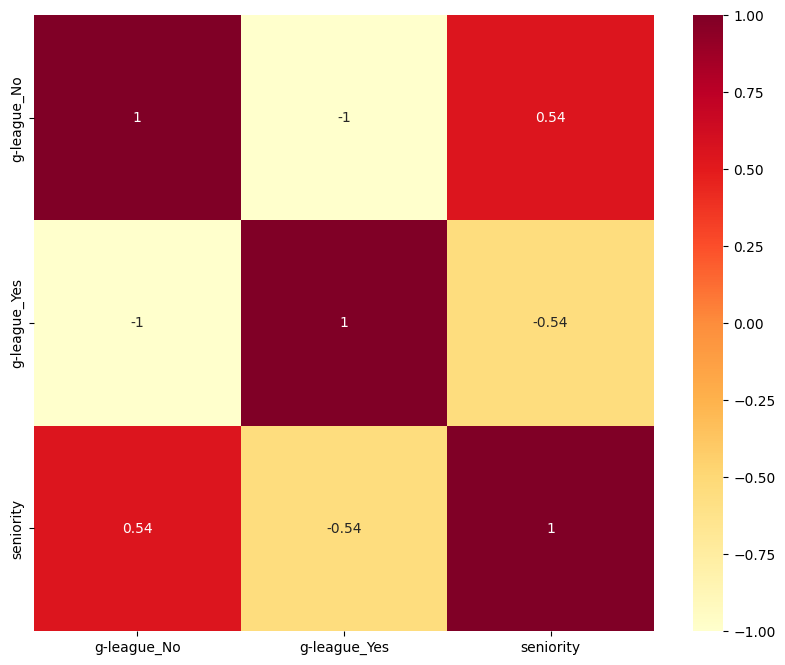

In [62]:
#Generamos el gráfico
gleague_col = df_corr_gleague.columns

#Generamos el gráfico
corr_fig(df_corr_gleague, gleague_col)

Conclusiones: 
- Al ser una variable con solo dos categorías es esperable que sean simetricamente opuestas. 
- Hay una cosa que nos llama la atención y es que los jugadores que han pasado por la gleague tienden a tener carreras notablemente más cortas. Esto se puede deber a que suelen ser perfiles menos consolidados como jugadores.

- Columna greatest_75_flag

In [63]:
#Creamos las nuevas columnas con las categóricas
dummies_greatest_75 = pd.get_dummies(df_EDA[['greatest_75_flag']])

#Creamos un dataset con las nuevas columnas y la columna seniority 
df_corr_greatest_75 = pd.concat([dummies_greatest_75, df_EDA[['seniority']]], axis = 1)

print ("Dataset generado")

Dataset generado


In [65]:
corr_greatest_75 = df_corr_greatest_75.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_greatest_75)

seniority               1.000000
greatest_75_flag_Yes    0.224455
greatest_75_flag_No    -0.224455
Name: seniority, dtype: float64


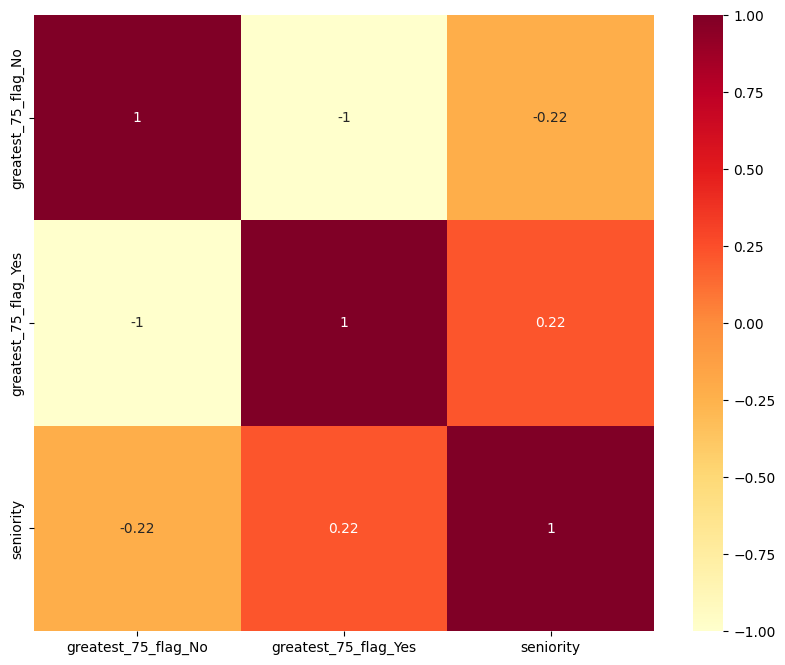

In [66]:
#Generamos el gráfico
greatest_75_col = df_corr_greatest_75.columns

#Generamos el gráfico
corr_fig(df_corr_greatest_75, greatest_75_col)

Conclusiones: 
- Como era de esperar, los jugadores que están en el selecto club de los 75 mejores de la historia tienden a tener carreras más largas. Esto es coherente, pero llama la atención que la fuerza de la correlación es menor a la esperada.

- Columna hub

In [67]:
#Creamos las nuevas columnas con las categóricas
dummies_hub = pd.get_dummies(df_EDA[['hub']])

#Creamos un dataset con las nuevas columnas y la columna seniority 
df_corr_hub = pd.concat([dummies_hub, df_EDA[['seniority']]], axis = 1)

print ("Dataset generado")

Dataset generado


In [68]:
corr_hub = df_corr_hub.corr(numeric_only= True)['seniority'].sort_values(ascending = False)
print (corr_hub)

seniority             1.000000
hub_USA               0.094540
hub_Caribbean        -0.000682
hub_Oceania          -0.008720
hub_Western Europe   -0.020851
hub_Asia             -0.028375
hub_Eastern Europe   -0.031043
hub_North America    -0.035983
hub_Latin America    -0.042999
hub_Africa           -0.085360
Name: seniority, dtype: float64


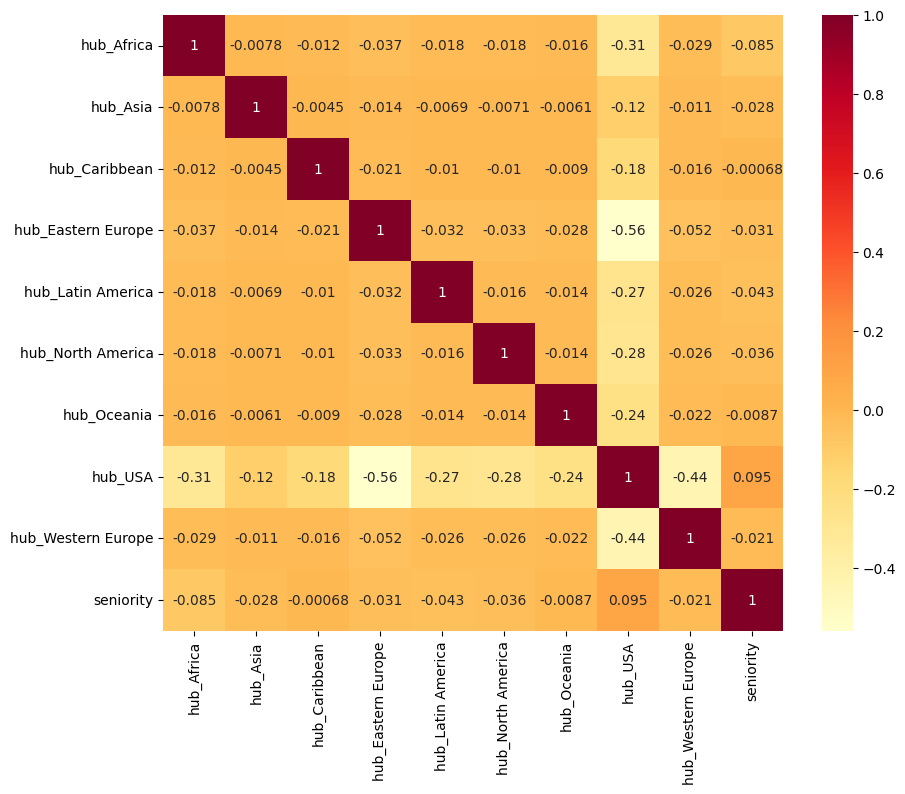

In [69]:
#Generamos el gráfico
hubs_col = df_corr_hub.columns

#Generamos el gráfico
corr_fig(df_corr_hub, hubs_col)

Conclusiones: 
- Todas las regiones muestran correlaciones muy débiles como para tenerlas en cuenta como factor determinante de la longevidad de un jugador.
- Los jugadores americanos son los únicos que muestran nuna correlación positiva lo que indica que tienen carreras ligeramente más largas. 

**3. Insights**

3.1 Perfil del dataset tras la limpieza

El dataset recoge información de 3661 jugadores de la NBA que jugaron entre 1978 y 2022 con una concentración especial de jugadores que jugaron entre 2003 y 2016.

3.2 Perfil de jugador NBA analizado 
- El jugador NBA promedio según nuestros análisis presenta una altura media de 200cm y un peso de 100 kg. 

- El 82,5% de los jugadore son americanos. Por tanto nuestro jugador promedio es americano. 

- El 64,5% de los jugadores provienen del sistema universitario por lo que nuestro jugador promedio proviene de ahí.

3.3 Influencia en la carrera del jugador.

- Duración de la carrera:

El jugador promedio juega 8,5 temporadas de promedio con un rango que va de 1 a 22 temporadas. 
El 50% de los jugadores juega entre 4 y 12 temporadas lo que refleja la competitividad en la liga.

- Impacto de la formación: 

Los jugadores que empiezan en el sector escolar americano tienden a tener carreras más largas. 

- Impacto del draft: 

Los jugadores que son elegidos en el draft tienen carreras más largas que aquellos que acceden a la liga a través de vías alternativas.

- Impacto de las características físicas: 

La altura de un jugador no parece ser determinante en la carrera de un jugador. En cambio, los jugadores más pesados tienden a tener carreras ligeramente más largas.

- Impacto de la posición:

La posición en la que juega un jugador tiene un impacto un débil en la carrera de los jugadores. Pero, los jugadores en posiciones interiores tienden a tener carreras ligeramente más largas.

- Impacto del número de equipos 

Los jugadores con carreras más largas tienden a cambiar más de equipo. Esto nos sugiere también que los jugadores capaces de adaptarse a distintos sistemas de juego y entornos tienden a durar más en la liga.

- Impacto de la liga de desarrollo (G-league): 

Los jugadores que pasan por la liga de desarrollo de suelen tener carreras más cortas.

- Impacto de la excelencia deportiva (Greatest 75):

Los jugadores incluidos en la lista de los 75 mejores tienden como es de esperar a tener carreras más largas pero sorprendentemente la diferencia en las carreras es moderada y no una gran diferencia. 

- Impacto de la procedencia: 

Con respecto al impacto de la procedencia, es muy limitado y no hay nada destacable.



**4. Conclusión**

El perfil de jugador de NBA con la probabilidad de tener una carrera duradera en la liga es un jugador interior formado en el sistema universitario, seleccionado en el draft, que no ha pasado por la G-league. con un físico corpulento y gran capacidad de adaptación a distintos esquemas de juego.